#Challenge Telecom X: análisis de evasión de clientes
##1. Introduccion:
El objetivo de este análisis es entender la evasión de clientes (Churn) en la empresa de telecomunicaciones, identificando patrones en las características de los clientes que cancelan el servicio.

El Churn es un indicador crítico para cualquier empresa de servicios, ya que mantener clientes existentes es más rentable que adquirir nuevos. Este análisis busca:


*   Conocer la proporción de clientes que cancelan vs los que permanecen.
*   Identificar variables que influyen en la probabilidad de abandono.
*   Generar insights que permitan diseñar estrategias para reducir la evasión.

##2. Limpieza y Tratamiento de Datos

Se realizaron los siguientes pasos para garantizar que los datos estén limpios y consistentes para el análisis:

* **Carga y Estructuración:** Carga de datos desde un archivo JSON y conversión a DataFrame.
* **Normalización de Columnas:** Desglose de variables anidadas con los siguientes renombramientos:
    * `customer.gender` $\rightarrow$ **customer_gender**
    * `account.Charges.Monthly` $\rightarrow$ **account_Charges_Monthly**
* **Calidad de Datos:** Revisión de valores faltantes y duplicados. No se encontraron valores nulos.
* **Corrección de Formatos:** Conversión de **account_Charges_Total** a tipo numérico para habilitar el análisis estadístico.
* **Ingeniería de Variables:** Creación de la métrica **Cuentas_Diarias**, que representa el gasto diario aproximado calculado como:
$$\text{Cuentas\_Diarias} = \frac{\text{facturación mensual}}{30}$$
* **Estandarización Categórica:** Transformación de variables binarias (como **Churn**, **Partner** y **Dependents**) en formato **0/1** para facilitar el modelado.

✅ **Resultado:** Datos optimizados y listos para la fase de análisis.

#📌 Extracción

In [85]:
#cargamos datos y convertimos en un dataframe
import pandas as pd
url='https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
df=pd.read_json(url)
df.head(3)
df.shape


(7267, 6)

Normalizamos el json

In [86]:
df = pd.json_normalize(df.to_dict(orient="records"))
df.head(3)
df.columns = df.columns.str.replace(".", "_")
df.head(4)
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


#🔧 Transformación
## Exploramos y conocemos el conjunto de datos


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [88]:
df.dtypes

,0
customerID,object
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


Se exploró la estructura del dataset utilizando df.info() y df.dtypes, lo que permitió identificar los tipos de datos de cada variable. El dataset contiene variables categóricas relacionadas con servicios contratados, características demográficas del cliente y variables numéricas relacionadas con el tiempo de permanencia y los cargos. La variable objetivo del análisis es Churn, que indica si un cliente abandonó o no la empresa. El dataset contiene 7267 registros y 21 variables relacionadas con características demográficas, servicios contratados, tipo de contrato y cargos asociados a los clientes. No se encontraron valores nulos en las variables. La mayoría de las columnas corresponden a variables categóricas, mientras que algunas variables numéricas como customer_tenure y account_Charges_Monthly representan el tiempo de permanencia del cliente y los cargos mensuales.


#Comprobación de incoherencias en los datos

In [89]:
#1. Verificamos valores faltantes
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [90]:
#2. Verificamos duplicados
df.duplicated().sum()

np.int64(0)

In [91]:
df['customerID'].duplicated().sum()

np.int64(0)

In [92]:
#Revisar inconsistencias en categorías
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [93]:
#por genero
df['customer_gender'].unique()

array(['Female', 'Male'], dtype=object)

In [94]:
(df['Churn'] == '').sum()

np.int64(224)

In [95]:
# Corregimos vaalores faltantes
import numpy as np
df['Churn'] = df['Churn'].replace('', np.nan)

In [96]:
df = df.dropna(subset=['Churn'])

In [97]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [98]:
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

In [99]:
#Creamos una nueva columna Cuentas_Diarias que  Uutiliza la facturación mensual para calcular el valor diario
df['Cuentas_Diarias'] = df['account_Charges_Monthly'] / 30

In [100]:
df[['account_Charges_Monthly','Cuentas_Diarias']].head()

,account_Charges_Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Se realizó una revisión de la calidad de los datos verificando valores faltantes, duplicados e inconsistencias en las variables categóricas. No se encontraron valores nulos ni registros duplicados en el dataset. Asimismo, se revisaron las categorías utilizando la función unique() para asegurar que los valores fueran consistentes. Finalmente, se identificó que la variable account_Charges_Total se encontraba en formato texto, por lo que fue convertida a formato numérico para facilitar el análisis posterior.

In [101]:
#Estandarizamos
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
cols_binarias = [
    'customer_Partner',
    'customer_Dependents',
    'phone_PhoneService',
    'account_PaperlessBilling'
]

for col in cols_binarias:
    df[col] = df[col].map({'Yes':1, 'No':0})

Se realizó una etapa de estandarización de datos en la cual se transformaron variables categóricas binarias como "Yes" y "No" en valores numéricos (1 y 0). Además, se revisaron los nombres de columnas para mejorar su claridad y facilitar la interpretación de los resultados durante el análisis exploratorio.

#📊 Carga y análisis

## Analisis descriptivo



##3. Análisis Exploratorio de Datos (EDA)
###3.1. Distribucion general de Churn



**Proporcion clientes que cancelaron vs clientes que permanecen**

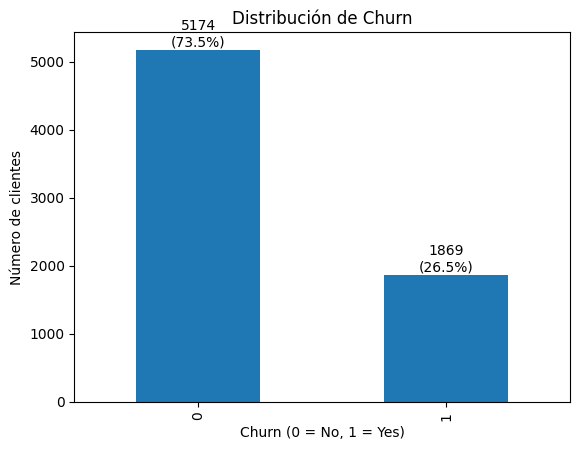

In [102]:
import matplotlib.pyplot as plt

conteo = df['Churn'].value_counts()
total = conteo.sum()

ax = conteo.plot(kind='bar')

for i, v in enumerate(conteo):
    porcentaje = v / total * 100
    ax.text(i, v + 50, f'{v}\n({porcentaje:.1f}%)', ha='center')

plt.title('Distribución de Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Número de clientes')
plt.show()

**Insight:** La mayoría de los clientes permanece, pero un 26.5% ha cancelado, lo que indica un **desbalance** moderado que merece atención.

##**Churn según variables categóricas**
Se analizó la tasa de evasión dentro de cada categoría de variables clave:
### 3.2.1. Genero

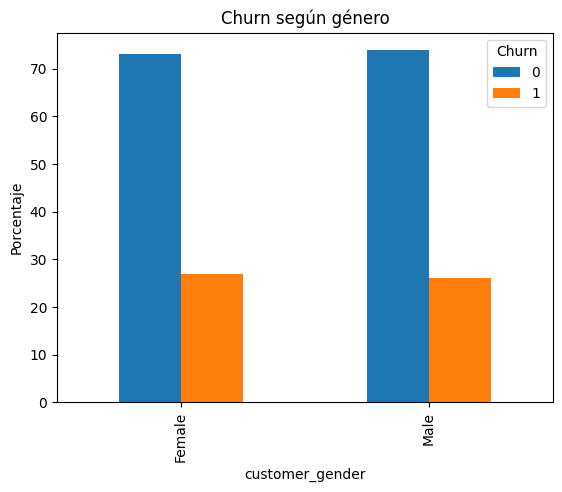

In [103]:
tabla = df.groupby(['customer_gender','Churn']).size().unstack()
porcentaje = tabla.div(tabla.sum(axis=1), axis=0) * 100
porcentaje.plot(kind='bar')
plt.title('Churn según género')
plt.ylabel('Porcentaje')
plt.show()

**Insight:** Hombres y mujeres presentan tasas de churn similares (~26–27%), indicando que **el género no afecta significativamente la evasión.**

### 3.2.2 Tipo de contrato

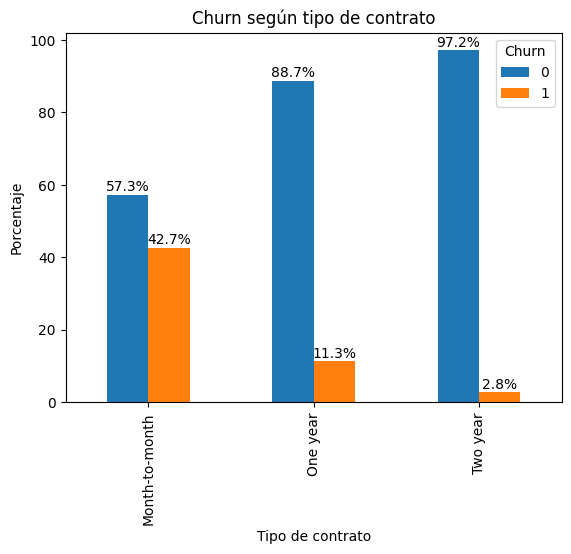

In [104]:
tabla = df.groupby(['account_Contract','Churn']).size().unstack()

porcentaje = tabla.div(tabla.sum(axis=1), axis=0) * 100

ax = porcentaje.plot(kind='bar')

for p in ax.patches:
    valor = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        valor + 1,
        f'{valor:.1f}%',
        ha='center'
    )

plt.title('Churn según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje')

plt.show()

**Insight:** Los clientes con contrato mensual tienen una tasa de churn mucho más alta que aquellos con contratos a 1 o 2 años.

### 3.2.3 Metodo de pago

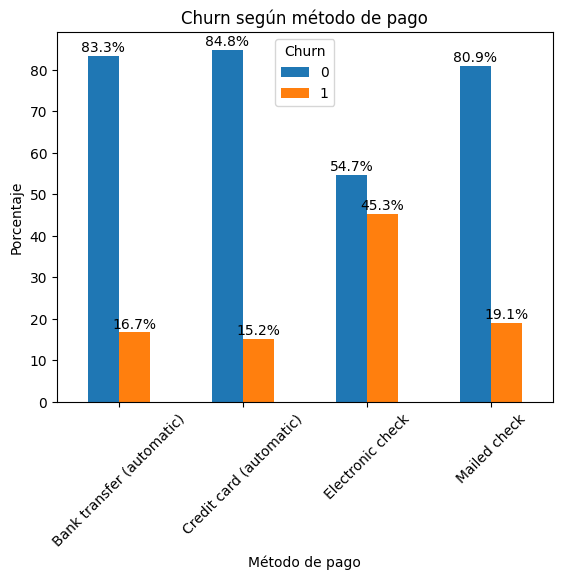

In [105]:
tabla = df.groupby(['account_PaymentMethod','Churn']).size().unstack()

porcentaje = tabla.div(tabla.sum(axis=1), axis=0) * 100

ax = porcentaje.plot(kind='bar')

for p in ax.patches:
    valor = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        valor + 1,
        f'{valor:.1f}%',
        ha='center'
    )

plt.title('Churn según método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Porcentaje')

plt.xticks(rotation=45)

plt.show()

**Insight:** Algunos métodos, como electronic check, muestran un churn más alto que otros métodos, lo que puede indicar fricción en pagos automáticos.

### 3.2.4 Tipo de servicio de internet

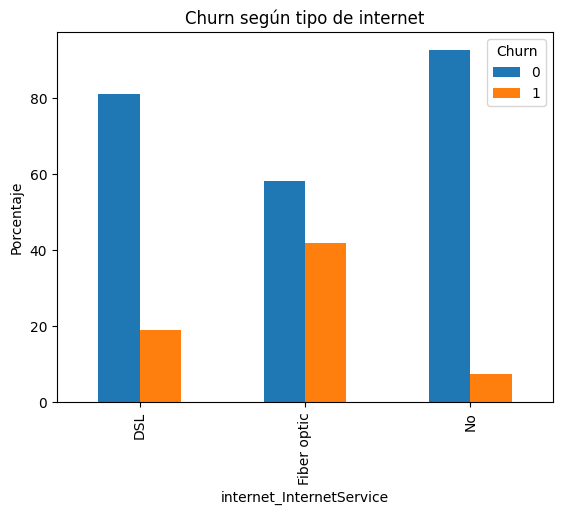

In [106]:
tabla = df.groupby(['internet_InternetService','Churn']).size().unstack()
porcentaje = tabla.div(tabla.sum(axis=1), axis=0) * 100
porcentaje.plot(kind='bar')
plt.title('Churn según tipo de internet')
plt.ylabel('Porcentaje')
plt.show()

##3.2.5. Churn segun el tiempo como cliente

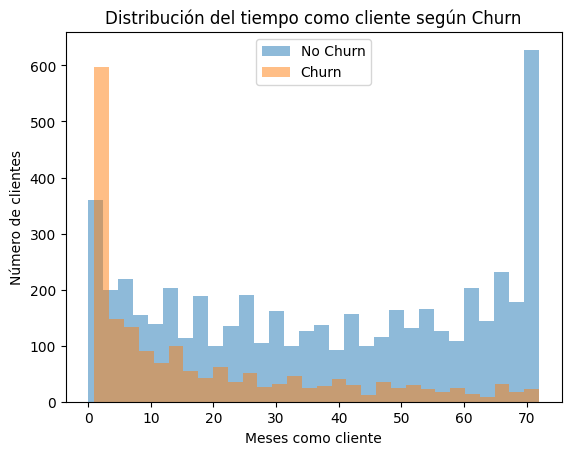

In [107]:
import matplotlib.pyplot as plt

plt.hist(df[df['Churn']==0]['customer_tenure'], bins=30, alpha=0.5, label='No Churn')
plt.hist(df[df['Churn']==1]['customer_tenure'], bins=30, alpha=0.5, label='Churn')

plt.title('Distribución del tiempo como cliente según Churn')
plt.xlabel('Meses como cliente')
plt.ylabel('Número de clientes')

plt.legend()

plt.show()

#3.3 Churn según variables numéricas
Se analizaron las variables numéricas para ver cómo se distribuyen entre clientes que cancelaron y los que permanecen.

##3.3.1 Tiempo de permanencia(Tenure)

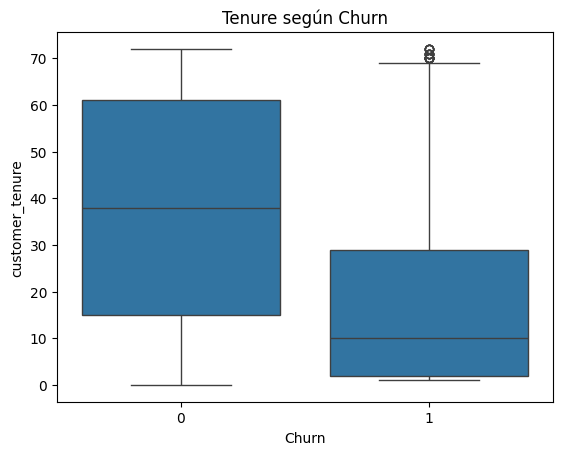

In [108]:
import seaborn as sns
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title('Tenure según Churn')
plt.show()

#3.3.2 Churn segun cargos  mensuales

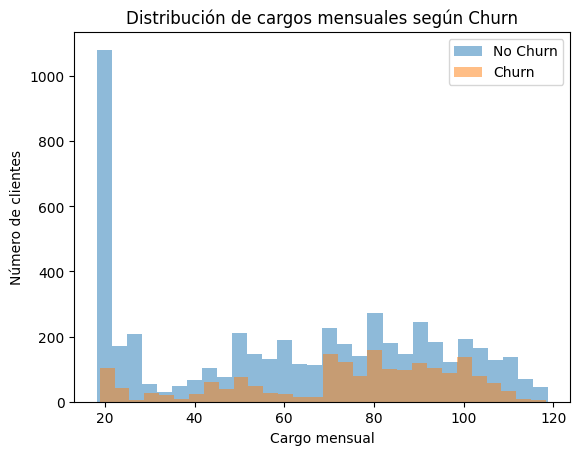

In [109]:
plt.hist(df[df['Churn']==0]['account_Charges_Monthly'], bins=30, alpha=0.5, label='No Churn')
plt.hist(df[df['Churn']==1]['account_Charges_Monthly'], bins=30, alpha=0.5, label='Churn')

plt.title('Distribución de cargos mensuales según Churn')
plt.xlabel('Cargo mensual')
plt.ylabel('Número de clientes')

plt.legend()

plt.show()

##3.3.3 Gasto Total

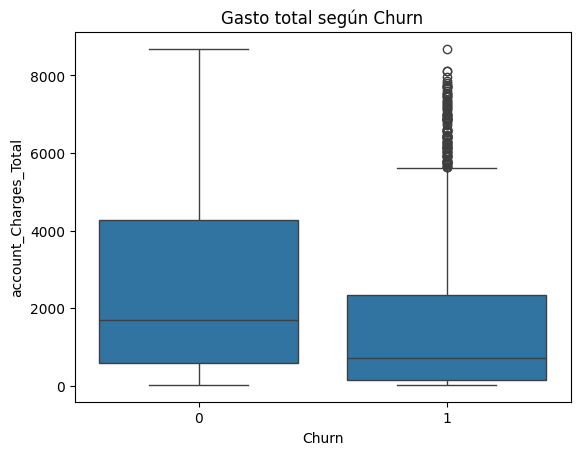

In [110]:
sns.boxplot(x='Churn', y='account_Charges_Total', data=df)
plt.title('Gasto total según Churn')
plt.show()

## Conclusiones e Insights

- **Tasa general de churn:**  
  El **26.5% de los clientes cancelaron el servicio**, mientras que el **73.5% permanecen** en la empresa.

### Variables categóricas más relevantes

- **`account_Contract`**  
  Los clientes con **contratos mensuales (Month-to-month)** presentan una **mayor tasa de churn** en comparación con aquellos con contratos de **1 o 2 años**.

- **`internet_InternetService`**  
  Los clientes que utilizan **Fiber optic** muestran una **mayor probabilidad de cancelar el servicio** en comparación con otros tipos de conexión como DSL.

- **`account_PaymentMethod`**  
  Algunos métodos de pago, como **electronic check**, presentan **tasas de churn más elevadas**, lo que podría indicar posibles fricciones en el proceso de pago.

### Variables numéricas

- **Antigüedad del cliente (`customer_tenure`)**  
  Los clientes con **poca antigüedad en la empresa** tienen una **mayor probabilidad de cancelar el servicio**.

- **Gasto total (`account_Charges_Total`)**  
  Los clientes con **menor gasto acumulado** presentan **mayores niveles de churn**, lo cual es coherente con el hecho de que suelen ser clientes más nuevos.

### Variables menos relevantes

Algunas variables no mostraron diferencias significativas en la tasa de churn:

- **Género**
- **Presencia de pareja (`Partner`)**
- **Dependientes (`Dependents`)**

Esto sugiere que **factores demográficos básicos no influyen significativamente en la cancelación del servicio**.

---

## Recomendaciones Estratégicas

### Incentivar contratos a largo plazo

Promover contratos de **1 o 2 años** ofreciendo **descuentos, beneficios adicionales o promociones exclusivas**, con el fin de reducir la tasa de churn asociada a los contratos mensuales.

### Reducir fricción en métodos de pago

Analizar a los clientes que utilizan **electronic check** y ofrecer **métodos de pago alternativos o automatizados**, como pagos automáticos con tarjeta o débito bancario.

### Mejorar el onboarding de nuevos clientes

Dado que los clientes nuevos presentan mayor churn, se recomienda implementar:

- Programas de **bienvenida**
- **Soporte técnico proactivo**
- Comunicación temprana para resolver dudas o problemas iniciales

### Atención a clientes con servicio Fiber optic

Dado que este grupo presenta mayor tasa de cancelación, se recomienda:

- Mejorar la **calidad del servicio**
- Ofrecer **incentivos o beneficios exclusivos**
- Implementar programas de **retención específicos**

---

## Resumen

El análisis permitió **identificar claramente los perfiles de clientes con mayor riesgo de abandono**, especialmente aquellos con **contratos mensuales, poca antigüedad y ciertos métodos de pago**.

Estos hallazgos proporcionan información valiosa para que la empresa pueda **diseñar estrategias de retención más efectivas**, mejorar la experiencia del cliente y reducir la tasa de churn.